### NYC Block-Level Population Analysis

This notebook prepares a block-level population dataset for New York City using 2020 Census data from NHGIS. Census block geometries for New York State are filtered to the five NYC boroughs (Bronx, Brooklyn, Manhattan, Queens, and Staten Island) and joined with total population counts at the block level. The resulting dataset is exported for use in future spatial analyses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors

<Axes: >

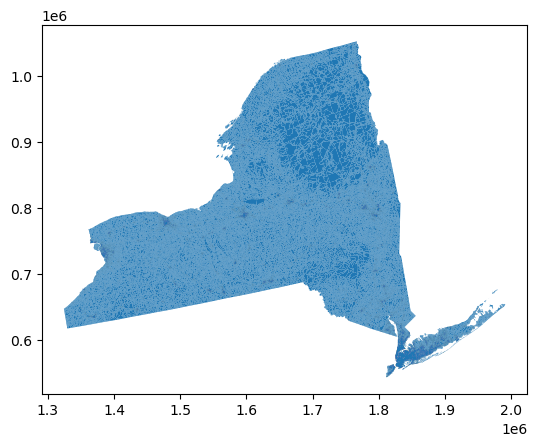

In [2]:
# Load and filter shapefile
NY_block_all = gpd.read_file("nhgis0003_shape/NY_block_2020.shp")
NY_block_all.plot()

In [3]:
NY_block_all.head(3)
print(NY_block_all.columns)

Index(['GISJOIN', 'STATEFP20', 'COUNTYFP20', 'TRACTCE20', 'BLOCKCE20',
       'GEOID20', 'NAME20', 'MTFCC20', 'UR20', 'UACE20', 'UATYPE20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='str')


In [4]:
NY_block_all["COUNTYFP20"].dtype

<StringDtype(storage='python', na_value=nan)>

In [5]:
NYC_FIPS = ["005", "047", "061", "081", "085"]
BOROUGH_NAMES = {
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island",
}

In [6]:
nyc_blocks = NY_block_all[NY_block_all["COUNTYFP20"].isin(NYC_FIPS)].copy()
nyc_blocks["borough"] = nyc_blocks["COUNTYFP20"].map(BOROUGH_NAMES)

In [14]:
print(nyc_blocks.crs)

PROJCS["USA_Contiguous_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",37.5],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102003"]]


In [18]:
# Dissolve blocks to create borough-level geometries
nyc_boundary = nyc_blocks.dissolve().to_crs("epsg:4326")
nyc_boundary.to_file("nyc_boundary.geojson", driver="GeoJSON")

<Axes: >

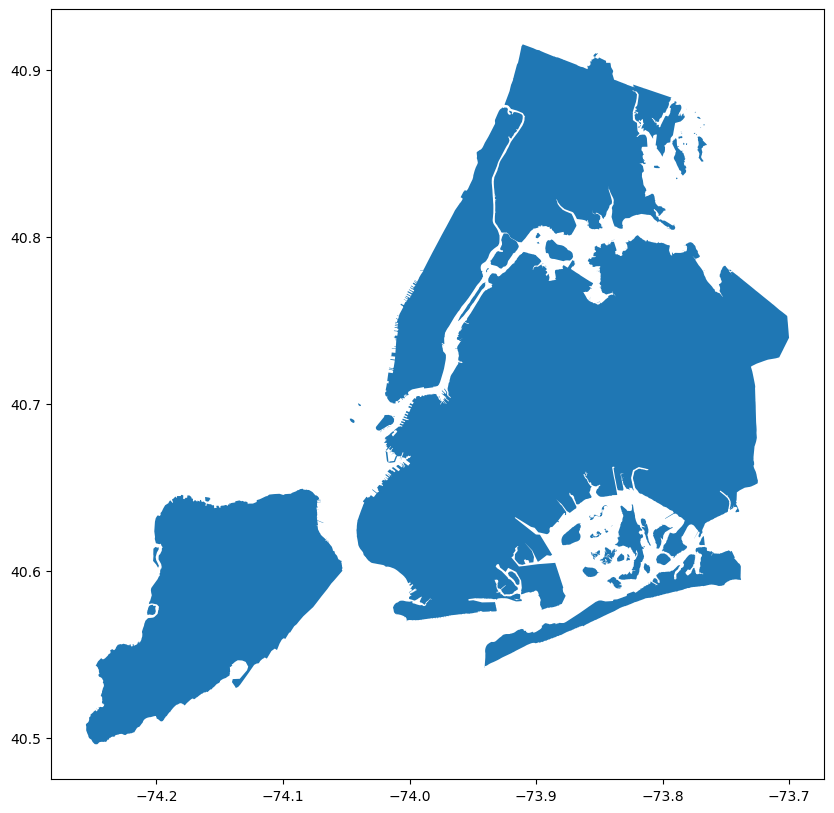

In [19]:
# Load and plot the saved GeoJSON
nyc_boundary_loaded = gpd.read_file("nyc_boundary.geojson")
nyc_boundary_loaded.plot(figsize=(10, 10))

In [7]:
print(f"NYC blocks: {len(nyc_blocks):,}")

NYC blocks: 37,480


In [8]:
# Load population csv
population = pd.read_csv(
    "nhgis0003_csv/nhgis0003_ds258_2020_block.csv",
    encoding="latin-1",
    usecols=["GISJOIN", "U7H001"],
)
population = population.rename(columns={"U7H001": "total_pop"})

In [9]:
print(population["total_pop"].describe())

count    288819.000000
mean         69.944322
std         150.371489
min           0.000000
25%           5.000000
50%          27.000000
75%          70.000000
max        5091.000000
Name: total_pop, dtype: float64


In [10]:
# Join population data with block shapefile
nyc_pop = nyc_blocks.merge(population, on="GISJOIN", how="left")

# Merge checks
n_unmatched = nyc_pop["total_pop"].isna().sum()
print(f"Unmatched blocks (no population): {n_unmatched:,} of {len(nyc_pop):,}")

Unmatched blocks (no population): 0 of 37,480


In [13]:
nyc_pop.head(3)

,GISJOIN,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,UR20,UACE20,...,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,Shape_Leng,Shape_Area,geometry,borough,total_pop
0,G36000500001001000,36,005,000100,1000,360050001001000,Block 1000,G5040,None,None,...,S,469092.0,0.0,+40.7892377,-073.8773641,6830.156709,469092.698143,"POLYGON ((1834236.911 582703.272, 1834243.734 ...",Bronx,171
1,G36000500001001001,36,005,000100,1001,360050001001001,Block 1001,G5040,None,None,...,S,518008.0,0.0,+40.7909952,-073.8802197,3234.417215,518008.039135,"POLYGON ((1834263.998 582941.378, 1834229.317 ...",Bronx,1344
2,G36000500001001002,36,005,000100,1002,360050001001002,Block 1002,G5040,None,None,...,S,13148.0,0.0,+40.7914102,-073.8843370,1561.988511,13147.826480,"POLYGON ((1834123.593 583604.538, 1834136.899 ...",Bronx,367


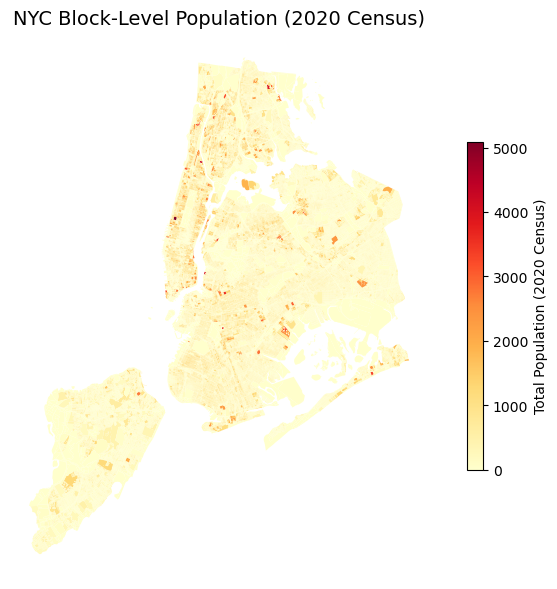

In [ ]:
# Map
fig, ax = plt.subplots(figsize=(8, 6))

nyc_pop.plot(
    column="total_pop",
    ax=ax,
    cmap="YlOrRd",
    linewidth=0,
    legend=True,
    legend_kwds={"label": "Total Population (2020 Census)", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

ax.set_title("NYC Block-Level Population (2020 Census)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

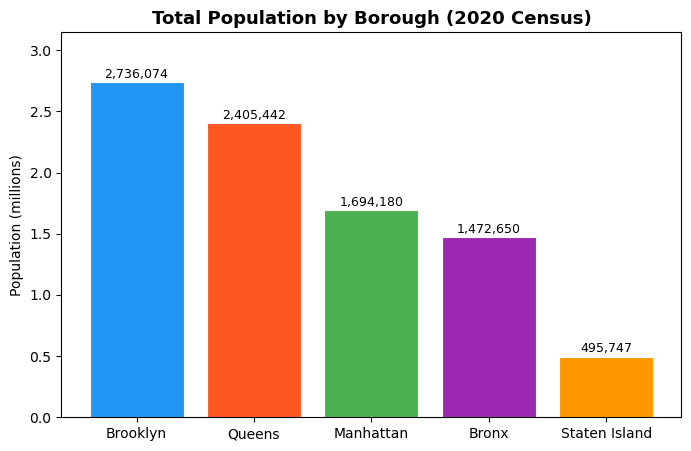

In [12]:
borough_pop = (
    nyc_pop.groupby("borough")["total_pop"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    borough_pop["borough"],
    borough_pop["total_pop"] / 1_000_000,
    color=["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"],
    edgecolor="white",
    linewidth=0.8,
)

for bar, val in zip(bars, borough_pop["total_pop"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(
    "Total Population by Borough (2020 Census)", fontsize=13, fontweight="bold"
)
ax.set_ylabel("Population (millions)")
ax.set_ylim(0, borough_pop["total_pop"].max() / 1_000_000 * 1.15)
plt.show()

In [ ]:
# test